# Instacart Market Basket Analysis - EDA
## Focus: Demand Forecasting & Customer Churn Prediction

**Project Goal:**
- Part 1: Forecast order demand by time/zone
- Part 2: Predict customer churn

**Dataset:** Instacart Market Basket Analysis (Kaggle)
- `orders.csv` - Order history with timestamps
- `order_products__*.csv` - Products in each order
- `products.csv` - Product metadata
- `aisles.csv` & `departments.csv` - Product categories

## 0. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# File paths
aisles_path = '../data/raw/aisles.csv'
departments_path = '../data/raw/departments.csv'
orders_path = '../data/raw/orders.csv'
products_path = '../data/raw/products.csv'
orders_prior_path = '../data/raw/order_products__prior.csv'
orders_train_path = '../data/raw/order_products__train.csv'

# Read the CSV file into a DataFrame
df_aisles = pd.read_csv(aisles_path)
df_departments = pd.read_csv(departments_path)
df_orders = pd.read_csv(orders_path)
df_products = pd.read_csv(products_path)
df_orders_prior = pd.read_csv(orders_prior_path)
df_orders_train = pd.read_csv(orders_train_path)

print("Data loaded successfully!")
print(f"Orders: {df_orders.shape}")
print(f"Order Products (train): {df_orders_train.shape}")
print(f"Order Products (prior): {df_orders_prior.shape}")
print(f"Products: {df_products.shape}")

Data loaded successfully!
Orders: (3421083, 7)
Order Products (train): (1384617, 4)
Order Products (prior): (32434489, 4)
Products: (49688, 4)


## 1. Data Overview & Structure

In [3]:
# Understanding the orders dataset
print("="*100)
print("ORDERS DATASET")
print("="*100)
print(df_orders.head(5))
print("\n" + "="*100)
print(df_orders.info())
print("\n" + "="*100)
print(df_orders.describe())

ORDERS DATASET
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow     

           order_id       user_id  order_number     order_dow  \
count  3.421083e+06  3.421083e+06  3.421083e+06  3.421083e+06   
mean   1.710542e+06  1.029782e+05  1.715486e+01  2.776219e+00   
std    9.875817e+05  5.953372e+04  1.773316e+01  2.046829e+00   
min    1.000000e+00  1.000000e+00  1.000000e+00  0.000000e+00   
25%    8.552715e+05  5.139400e+04  5.000000e+00  1.000000e+00   
50%    1.710542e+06  1.026890e+05  1.100000e+01  3.000000e+00   
75%    2.565812e+06  1.543850e+05  2.300000e+01  5.000000e+00   
max    3.421083e+06  2.062090e+05  1.000000e+02  6.000000e+00   

       order_hour_of_day  days_since_prior_order  
count       3.421083e+06            3.214874e+06  
mean        1.345202e+01            1.111484e+01  
std         4.226088e+00            9.206737e+00  
min         0.000000e+00            0.000000e+00  
25%         1.000000e+01            4.000000e+00  
50%         1.300000e+01            7.000000e+00  
75%         1.600000e+01            1.500000e+01  
max   

**KEY COLUMNS:**
- order_id: Unique order identifier
- user_id: Customer identifier (for churn analysis)
- order_number: Nth order for this user (1 = first order, useful for loyalty)
- order_dow: Day of week (0-6, for temporal patterns)
- order_hour_of_day: Hour when order placed (0-23, for demand forecasting)
- days_since_prior_order: Days since last order (churn signal!)
- eval_set: train/test/prior (data split)

## 2. Data Quality Assessment

**Critical for both forecasting and churn:**
- Missing values can break time series models
- Understanding data gaps helps define churn thresholds

                        Missing Count  Missing Percentage
days_since_prior_order         206209            6.027594
user_id                             0            0.000000
order_id                            0            0.000000
eval_set                            0            0.000000
order_number                        0            0.000000
order_dow                           0            0.000000
order_hour_of_day                   0            0.000000


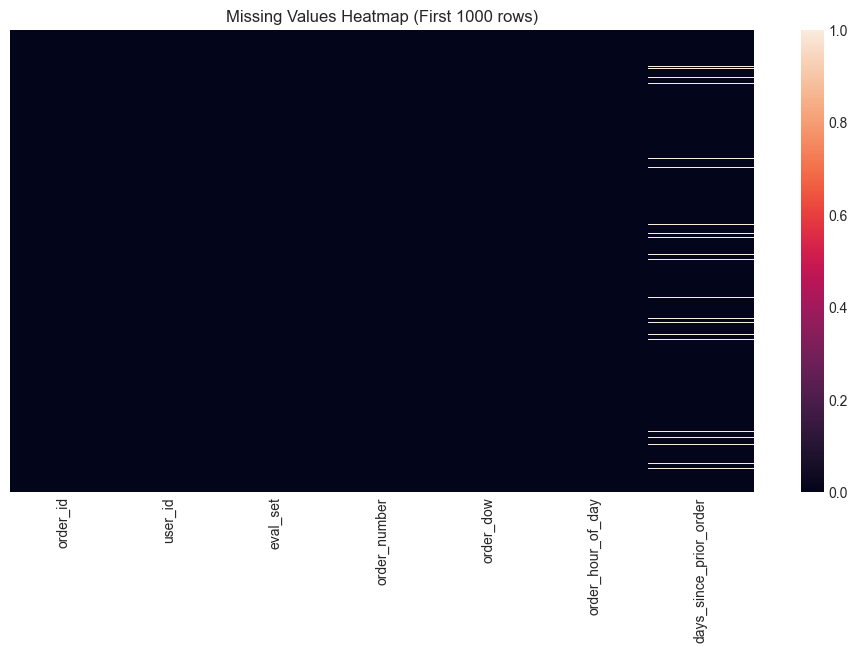

In [4]:
# Missing values analysis
missing = df_orders.isnull().sum()
missing_percent = (missing / len(df_orders)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage': missing_percent}).sort_values(by='Missing Percentage', ascending=False)

print(missing_df)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df_orders.isnull().head(1000), yticklabels=False)
plt.title('Missing Values Heatmap (First 1000 rows)')
plt.show()

### Insights:
- days_since_prior_order has missing values. First time customers have no prior order.

In [5]:
print(f"First orders (order_number=1): {(df_orders['order_number'] == 1).sum()}")
print(f"Missing days since prior order: {df_orders['days_since_prior_order'].isnull().sum()}")
print("These are matching because the first order for each user will not have a prior order.")

First orders (order_number=1): 206209
Missing days since prior order: 206209
These are matching because the first order for each user will not have a prior order.


In [6]:
# Duplicates check
print(f"Duplicate order_id: {df_orders['order_id'].duplicated().sum()}")
print(f"Duplicate user order sequence: {df_orders.duplicated(subset=['user_id', 'order_number']).sum()}")

Duplicate order_id: 0
Duplicate user order sequence: 0


## 3. DEMAND FORECASTING - Temporal Analysis

**Goal:** Understand order patterns by time to predict future demand

Key questions:
1. When do people order? (hourly patterns)
2. Which days are busiest? (weekly seasonality)
3. Are there trends over time? (growth/decline)
4. How consistent are patterns? (variance)

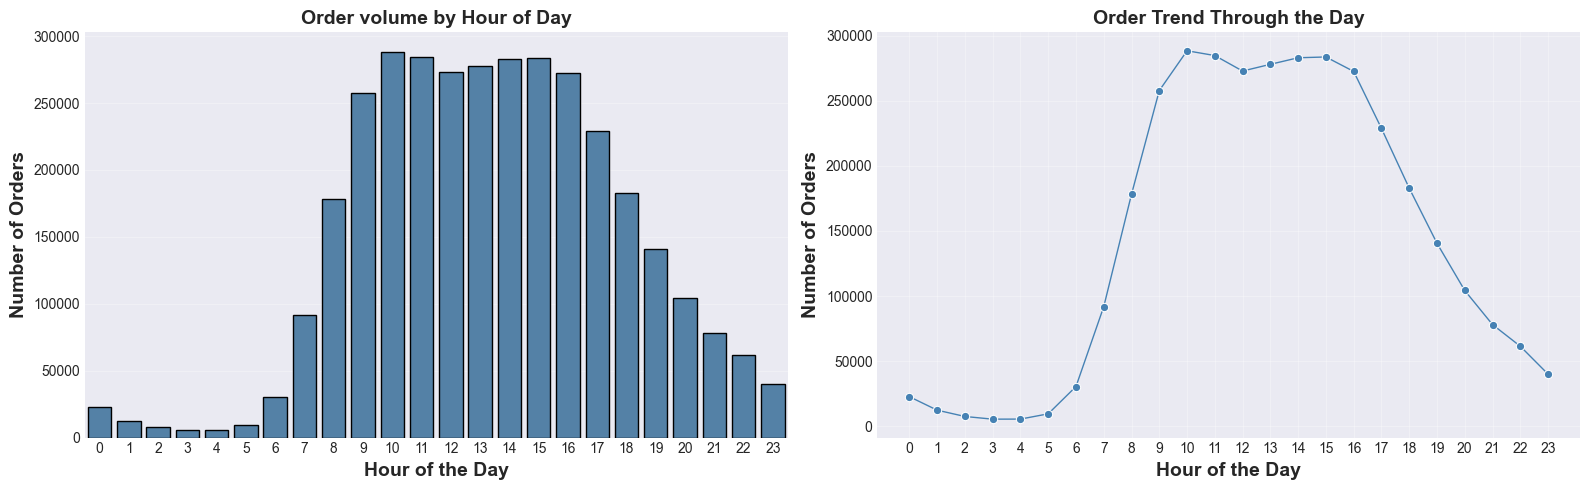

PEAK HOUR: 10:00 with 288418 orders
SLOWEST HOUR: 3:00 with 5474 orders


In [7]:
# Hourly ordering patterns
hourly_orders = df_orders.groupby('order_hour_of_day')['order_id'].count().reset_index(name='order_count')

# Bar chart
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=hourly_orders, x='order_hour_of_day', y='order_count',ax=ax[0], color='steelblue', edgecolor='black')
ax[0].set_xlabel('Hour of the Day', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Number of Orders', fontsize=14, fontweight='bold')
ax[0].set_title('Order volume by Hour of Day', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)
ax[0].set_xticks(range(0, 24))

# Line plot for trend
sns.lineplot(data=hourly_orders, x='order_hour_of_day', y='order_count',ax=ax[1], marker='o', linewidth=1, markersize=6, color='steelblue')
ax[1].set_xlabel('Hour of the Day', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Number of Orders', fontsize=14, fontweight='bold')
ax[1].set_title('Order Trend Through the Day', fontsize=14, fontweight='bold')
ax[1].grid(True, alpha=0.3)
ax[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Find peak hours
peak_hour = hourly_orders.loc[hourly_orders['order_count'].idxmax()]
slowest_hour = hourly_orders.loc[hourly_orders['order_count'].idxmin()]
print(f"PEAK HOUR: {int(peak_hour['order_hour_of_day'])}:00 with {int(peak_hour['order_count'])} orders")
print(f"SLOWEST HOUR: {int(slowest_hour['order_hour_of_day'])}:00 with {int(slowest_hour['order_count'])} orders")

### Insights:
- From hour 10 of the day to 16 is where the peak happens with minor changes.
- There is an upward trend starts to form at hour 6, and starts decaying at hour 16.

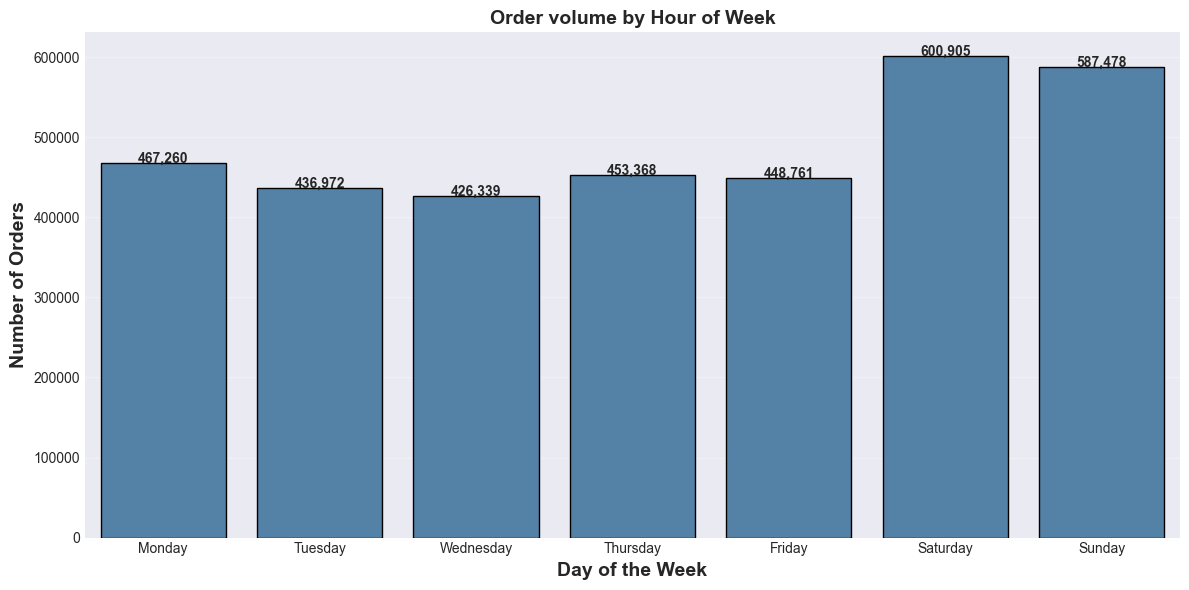

PEAK DAY: Saturday with 600905 orders
SLOWEST DAY: Wednesday with 426339 orders


In [8]:
# Daily ordering patterns
dow_mapping = {0: 'Saturday', 1: 'Sunday', 2: 'Monday', 3: 'Tuesday',
               4: 'Wednesday', 5: 'Thursday', 6: 'Friday'}
df_orders['day_name'] = df_orders['order_dow'].map(dow_mapping)

dow_orders = df_orders.groupby('day_name')['order_id'].count().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).reset_index(name='order_count')

# Bar chart
plt.figure(figsize=(12,6))
sns.barplot(data=dow_orders, x='day_name', y='order_count', color='steelblue', edgecolor='black')
plt.xlabel('Day of the Week', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=14, fontweight='bold')
plt.title('Order volume by Hour of Week', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value lables
for i,v in enumerate(dow_orders['order_count']):
    plt.text(i, v + 500, f'{int(v):,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#Find peak days
peak_day = dow_orders.loc[dow_orders['order_count'].idxmax()]
slowest_day = dow_orders.loc[dow_orders['order_count'].idxmin()]
print(f"PEAK DAY: {peak_day['day_name']} with {int(peak_day['order_count'])} orders")
print(f"SLOWEST DAY: {slowest_day['day_name']} with {int(slowest_day['order_count'])} orders")


### Insights:
- Weekends have the highest orders volume with saturday being slightly higher than sunday.
- Weekdays have noticiably lower orders volume than weekends with wednesday being the lowest.

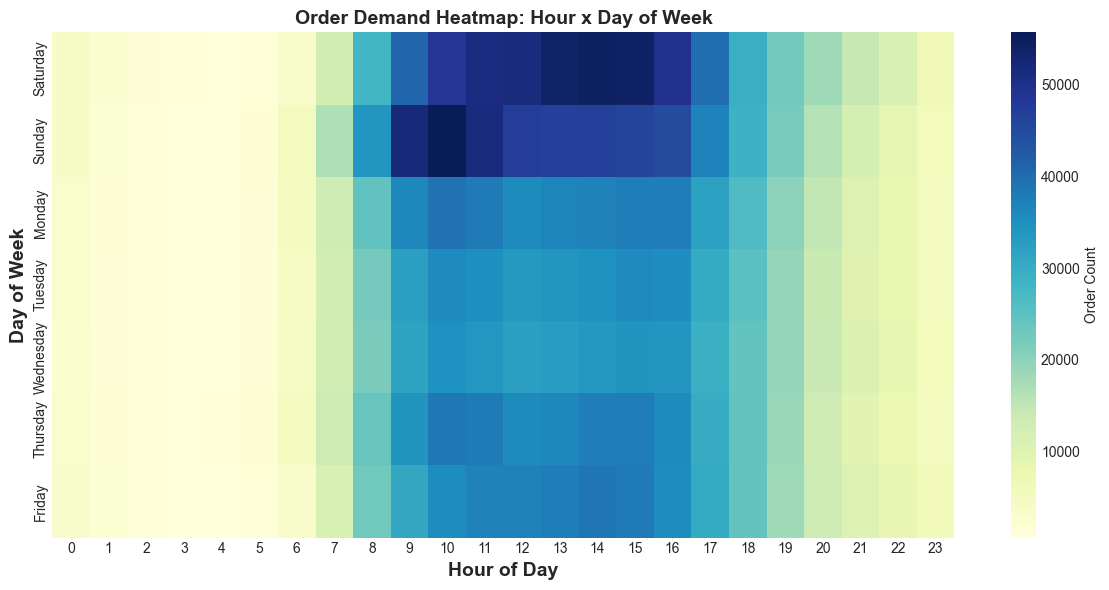


ABSOLUTE PEAK: Sunday at 10:00 (55,671 orders)


In [ ]:
# Daily and Hourly ordering patterns
hour_dow_matrix = df_orders.groupby(['order_dow', 'order_hour_of_day']).count()['order_id'].reset_index(name='order_count')
hour_dow_matrix = hour_dow_matrix.pivot_table(index='order_dow', columns='order_hour_of_day', values='order_count')
hour_dow_matrix.index = hour_dow_matrix.index.map(dow_mapping)

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(data=hour_dow_matrix, cmap='YlGnBu', annot=False, fmt='d', cbar_kws={'label': 'Order Count'})
plt.xlabel('Hour of Day', fontsize=14, fontweight='bold')
plt.ylabel('Day of Week', fontsize=14, fontweight='bold')
plt.title('Order Demand Heatmap: Hour x Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find peak days and hours
peak_index = hour_dow_matrix.stack().idxmax()
peak_orders = hour_dow_matrix.stack().max()
print(f"\nABSOLUTE PEAK: {peak_index[0]} at {int(peak_index[1])}:00 ({int(peak_orders):,} orders)")


### Insights:
- The orders volume are condensed in the days and hours we noticed from the previous graphs.
- Absolute peak happen on sunday at 10:00.

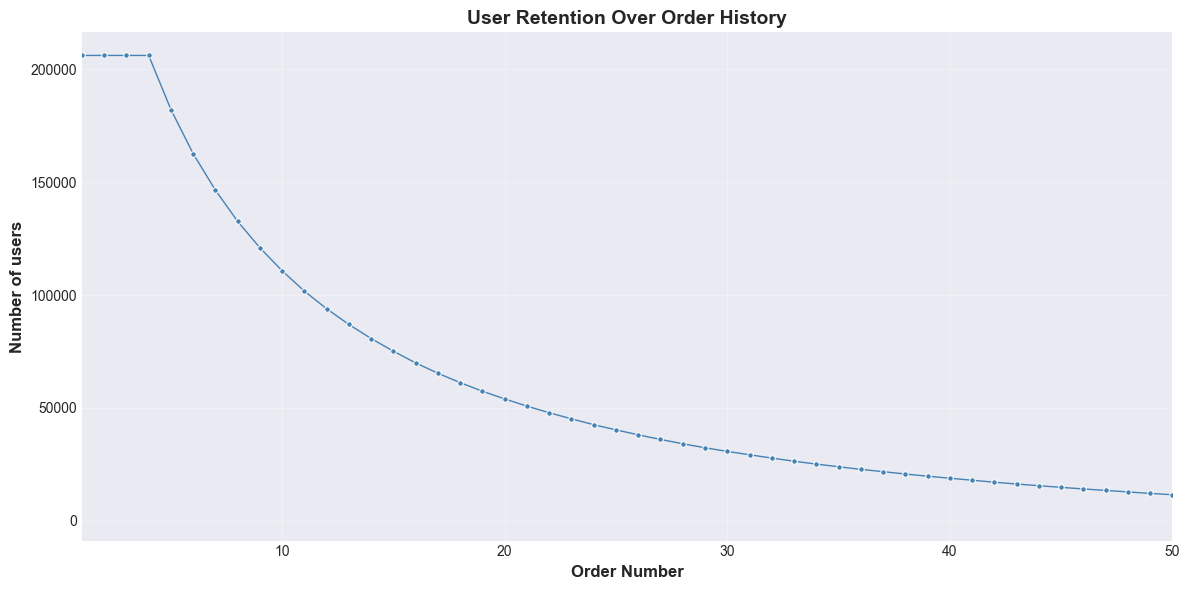

Users with 1+ order: 3421083
Users with 10+ order: 1851387
Users with 50+ order: 228334


In [ ]:
# Order growth over time
order_sequence = df_orders.groupby('order_number').count()['user_id'].reset_index(name='user_count')

# Lineplot
plt.figure(figsize=(12,6))
sns.lineplot(data=order_sequence, x='order_number', y='user_count', marker='o', linewidth=1, markersize=4, color='steelblue')
plt.xlabel('Order Number', fontsize=12, fontweight='bold')
plt.ylabel('Number of users', fontsize=12, fontweight='bold')
plt.title('User Retention Over Order History', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(1, 50) 
plt.tight_layout()
plt.show()

# Users order number
print(f"Users with 1+ order: {int(order_sequence[order_sequence['order_number']>=1]['user_count'].sum())}")
print(f"Users with 10+ order: {int(order_sequence[order_sequence['order_number']>=10]['user_count'].sum())}")
print(f"Users with 50+ order: {int(order_sequence[order_sequence['order_number']>=50]['user_count'].sum())}")

### Insights:
- It is clear that there is a noticable decay in the user retention as the users' order number increase.

## 4. CHURN PREDICTION

**Goal:** Identify patterns that signal a customer is about to churn

Key questions:
1. How do we define churn?
2. What's the churn rate?
3. How do churned users behave differently?
4. What features predict churn?

(0.0, 30.0)

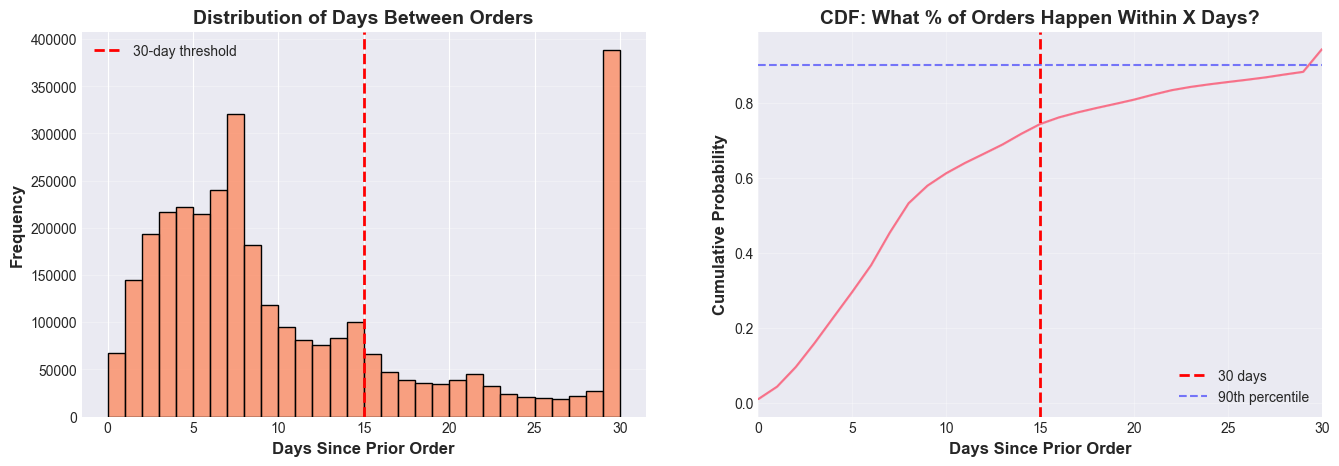

In [ ]:
days_since = df_orders['days_since_prior_order'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(16,5))

sns.histplot(data=days_since, ax=ax[0], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Days Since Prior Order', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax[0].set_title('Distribution of Days Between Orders', fontsize=14, fontweight='bold')
ax[0].axvline(15, color='red', linestyle='--', linewidth=2, label='30-day threshold')
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

sorted_days = np.sort(days_since)
cumulative = np.arange(1, len(sorted_days) + 1) / len(sorted_days)
sns.lineplot(x=sorted_days, y=cumulative, ax=ax[1])
ax[1].set_xlabel('Days Since Prior Order', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax[1].set_title('CDF: What % of Orders Happen Within X Days', fontsize=14, fontweight='bold')
ax[1].axvline(15, color='red', linestyle='--', linewidth=2, label='15 days')
ax[1].axhline(0.9, color='blue', linestyle='--', alpha=0.5, label='90th percentile')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(0, 30)

plt.tight_layout()
plt.show()



In [59]:
user_features = df_orders.groupby('user_id').agg({
    'order_id': 'count',
    'order_number': 'max',
    'days_since_prior_order': ['mean', 'max']
}).reset_index()

user_features.columns = ['user_id', 'total_orders', 'order_depth', 'avg_days_between', 'max_days_between']

user_features['churned'] = (user_features['max_days_between']>=30).astype(int)

print(user_features.head(10))
print(f"\nTotal users: {len(user_features):,}")
print(f"Churned users: {user_features['churned'].sum():,} ({user_features['churned'].mean()*100:.1f}%)")
print(f"Active users: {(1-user_features['churned']).sum():,} ({(1-user_features['churned'].mean())*100:.1f}%)")

   user_id  total_orders  order_depth  avg_days_between  max_days_between  \
0        1            11           11         19.000000              30.0   
1        2            15           15         16.285714              30.0   
2        3            13           13         12.000000              21.0   
3        4             6            6         17.000000              30.0   
4        5             5            5         11.500000              19.0   
5        6             4            4         13.333333              22.0   
6        7            21           21         10.450000              30.0   
7        8             4            4         23.333333              30.0   
8        9             4            4         22.000000              30.0   
9       10             6            6         21.800000              30.0   

   churned  
0        1  
1        1  
2        0  
3        1  
4        0  
5        0  
6        1  
7        1  
8        1  
9        1  

Total us